# 01. Exploratory Data Analysis (Claude edition)

This notebook combines the best of `01_eda.ipynb` and `eda-hf.ipynb`, then adds a dedicated block on **stationarity (ADF / KPSS), ACF, and PACF** — the piece both original notebooks were missing.

**Why we need this notebook**

Before we train any forecasting model (classical, ML, or deep learning), we need to answer four practical questions:

1. What does the panel look like, and how is it split between train and test?
2. How heavy-tailed is the target, and how concentrated are the weights?
3. Is the target **stationary**? (If not, classical models need differencing.)
4. What are the dominant **autocorrelation** lags? (They drive lag-feature choices and AR order.)

**Roadmap**

1. Schema and panel structure
2. Train vs test comparability
3. Missing values
4. Target distribution
5. Weight distribution and metric implications
6. Series coverage and split feasibility
7. Feature audit
8. Representative series
9. **Stationarity — ADF test**
10. **Stationarity — KPSS test (ADF complement)**
11. **Differencing analysis**
12. **Rolling mean / variance (visual stationarity)**
13. **ACF and PACF — anchor series**
14. **ACF and PACF — panel-level**
15. **Seasonality strength scan**
16. **Ljung-Box test (is there serial structure to exploit?)**
17. Cross-series relationships
18. Leakage and split sanity
19. Conclusions for modeling

## 0. Setup

We load train and test from the Kaggle dataset, fix a seed for reproducibility, and define a single `VAL_CUTOFF = 2880` that every later notebook uses as the train / validation boundary.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'ts-forecasting'
VAL_CUTOFF = 2880
SEED = 42
rng = np.random.default_rng(SEED)

train = pd.read_parquet(DATA_DIR / 'train.parquet')
test = pd.read_parquet(DATA_DIR / 'test.parquet')

feature_cols = [c for c in train.columns if c.startswith('feature_')]
series_keys = ['code', 'sub_code', 'sub_category', 'horizon']

print(f'Train: {train.shape}, Test: {test.shape}')
print(f'Features: {len(feature_cols)}, Series keys: {series_keys}')

Train: (5337414, 94), Test: (1447107, 92)
Features: 86, Series keys: ['code', 'sub_code', 'sub_category', 'horizon']


## 1. Schema and panel structure

We confirm the panel has `code` → `sub_code` → `sub_category` → `horizon` → `ts_index` as its keys, with `y_target` as the regression target and `weight` as the per-row metric weight.

In [56]:
overview = {
    'train_rows': len(train),
    'test_rows': len(test),
    'feature_count': len(feature_cols),
    'codes': train['code'].nunique(),
    'sub_codes_train': train['sub_code'].nunique(),
    'sub_codes_test': test['sub_code'].nunique(),
    'sub_categories': train['sub_category'].nunique(),
    'horizons': sorted(train['horizon'].unique().tolist()),
    'ts_index_train': (int(train['ts_index'].min()), int(train['ts_index'].max())),
    'ts_index_test': (int(test['ts_index'].min()), int(test['ts_index'].max())),
}
overview

{'train_rows': 5337414,
 'test_rows': 1447107,
 'feature_count': 86,
 'codes': 23,
 'sub_codes_train': 180,
 'sub_codes_test': 47,
 'sub_categories': 5,
 'horizons': [1, 3, 10, 25],
 'ts_index_train': (1, 3601),
 'ts_index_test': (3602, 4376)}

**Reading of this table.** The panel is large — ~5.3M train rows across 23 codes and 180 sub-codes. Test is a strictly later block (ts_index 3602 → 4376), so our validation strategy must respect time order (no random CV). The fact that test has only 47 sub-codes out of 180 means *generalization to a narrower sub-code universe* is part of the problem.

## 2. Train vs test comparability

If train and test live on different schemas or different supports, naive modeling breaks. We check column alignment first.

In [57]:
train_only = sorted(set(train.columns) - set(test.columns))
test_only = sorted(set(test.columns) - set(train.columns))
print('Columns in train only:', train_only)
print('Columns in test only:', test_only)

rows = []
for col in ['code', 'sub_code', 'sub_category', 'horizon']:
    rows.append({
        'column': col,
        'train_unique': train[col].nunique(),
        'test_unique': test[col].nunique(),
        'test_subset_of_train': set(test[col].unique()).issubset(set(train[col].unique())),
    })
pd.DataFrame(rows)

Columns in train only: ['weight', 'y_target']
Columns in test only: []


,column,train_unique,test_unique,test_subset_of_train
0,code,23,23,True
1,sub_code,180,47,False
2,sub_category,5,5,True
3,horizon,4,4,True


**Reading.** The only train-only columns are `y_target` and `weight`, which is exactly what we expect (test doesn't carry labels or metric weights). Every categorical level in test is also present in train — so we don't have a cold-start category problem. The narrower test sub-code universe is a coverage issue, not a schema issue.

## 3. Missing values

Imputation strategy follows directly from how much is missing and where.

In [58]:
missing = train.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f'Columns with any missing values: {len(missing)}')
print(f'Max missing rate: {missing.max():.3%}')
missing.head(10)

Columns with any missing values: 48
Max missing rate: 12.472%


feature_at    0.124719
feature_by    0.110192
feature_ay    0.085420
feature_cd    0.074964
feature_ce    0.051678
feature_cf    0.044289
feature_al    0.042233
feature_aw    0.038444
feature_bz    0.028426
feature_bi    0.027622
dtype: float64

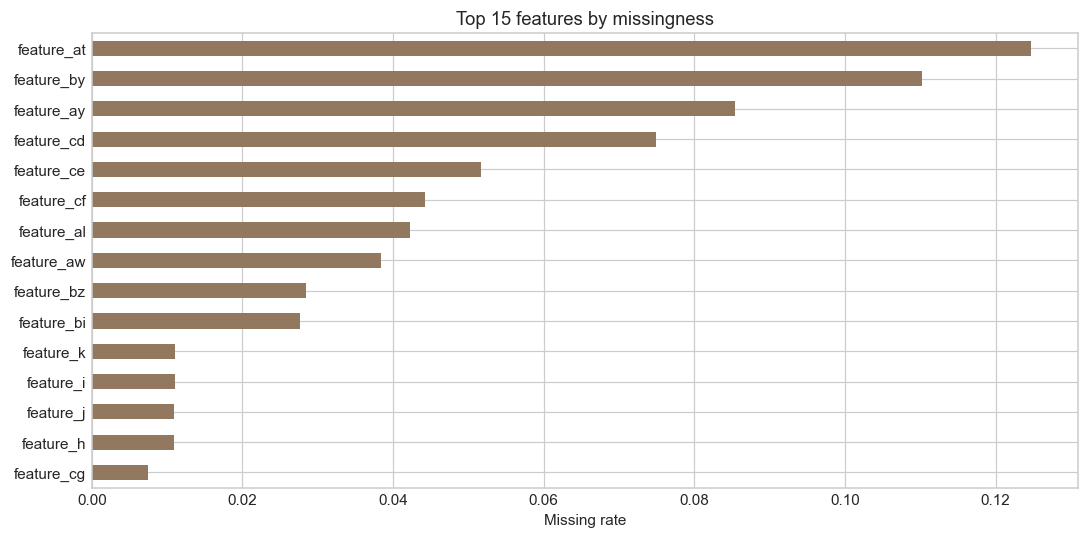

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))
missing.head(15).sort_values().plot.barh(ax=ax, color='#937860')
ax.set_xlabel('Missing rate')
ax.set_title('Top 15 features by missingness')
plt.tight_layout()
plt.show()

**Reading.** No feature exceeds ~12.5% missing, and most features are complete or near-complete. This is low enough that simple median imputation inside a pipeline will work; we don't need multiple imputation or anything fancy.

## 4. Target distribution

The target drives the metric, so we need to understand its scale, centering, and tails before choosing a loss or a baseline.

In [60]:
train['y_target'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    5.337414e+06
mean    -6.659048e-01
std      3.252764e+01
min     -2.201882e+03
1%      -8.279722e+01
5%      -7.606810e+00
25%     -1.290776e-01
50%     -5.774818e-04
75%      5.106807e-02
95%      4.504747e+00
99%      6.292342e+01
max      2.314411e+03
Name: y_target, dtype: float64

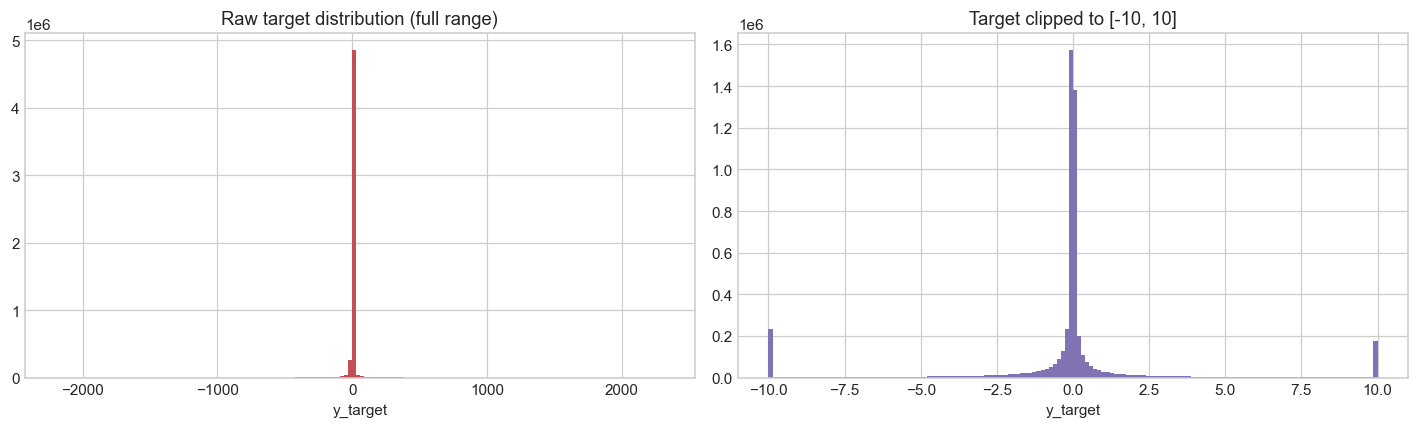

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['y_target'], bins=150, color='#C44E52')
axes[0].set_title('Raw target distribution (full range)')
axes[0].set_xlabel('y_target')

axes[1].hist(np.clip(train['y_target'], -10, 10), bins=150, color='#8172B3')
axes[1].set_title('Target clipped to [-10, 10]')
axes[1].set_xlabel('y_target')

plt.tight_layout()
plt.show()

**Reading.** The target is centered near zero (median ≈ 0) but has extremely heavy tails — the full range runs from about −2200 to +2300, even though the middle 50% lies between about −0.13 and +0.05. That tells us two things:

- RMSE-style losses will be dominated by a handful of extreme rows.
- Any non-robust baseline (plain mean) will be pulled by outliers.

## 5. Weight distribution and metric implications

The competition metric is **weighted** (weighted skill score). A few rows can dominate the ranking. We need to quantify this, not assume it is uniform.

In [62]:
w = train['weight'].sort_values(ascending=False).reset_index(drop=True)
cum_share = w.cumsum() / w.sum()

shares = {
    'top_1pct_share': float(cum_share.iloc[int(len(w) * 0.01) - 1]),
    'top_5pct_share': float(cum_share.iloc[int(len(w) * 0.05) - 1]),
    'top_10pct_share': float(cum_share.iloc[int(len(w) * 0.10) - 1]),
    'median_weight': float(train['weight'].median()),
    'max_weight': float(train['weight'].max()),
}
shares

{'top_1pct_share': 0.6418612969643038,
 'top_5pct_share': 0.9258065005764631,
 'top_10pct_share': 0.9833170811354748,
 'median_weight': 1699.3843705131449,
 'max_weight': 13912217783333.135}

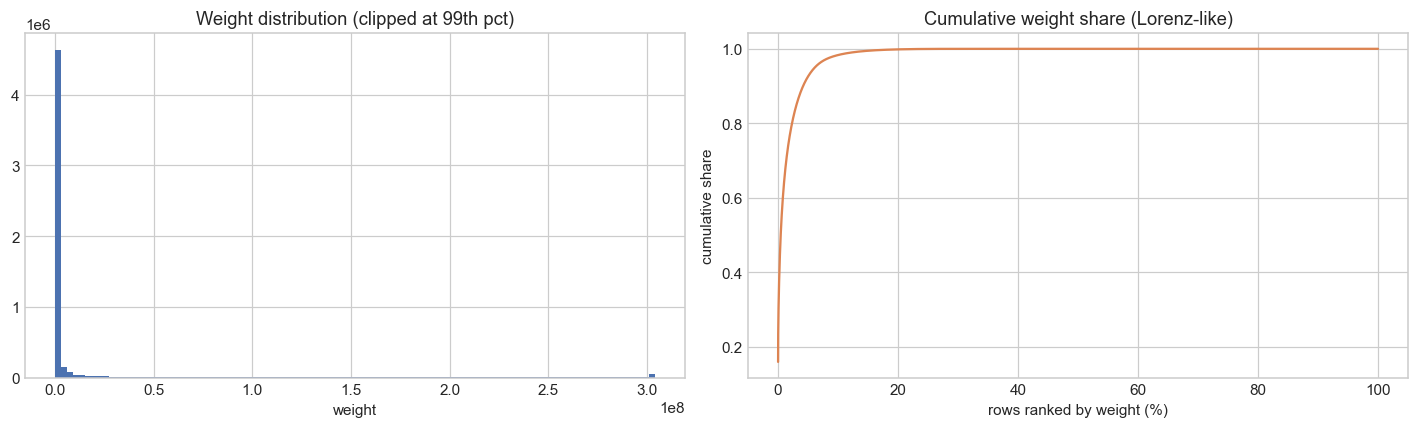

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.clip(train['weight'], 0, train['weight'].quantile(0.99)), bins=100, color='#4C72B0')
axes[0].set_title('Weight distribution (clipped at 99th pct)')
axes[0].set_xlabel('weight')

axes[1].plot(np.linspace(0, 100, len(cum_share)), cum_share, color='#DD8452')
axes[1].set_title('Cumulative weight share (Lorenz-like)')
axes[1].set_xlabel('rows ranked by weight (%)')
axes[1].set_ylabel('cumulative share')

plt.tight_layout()
plt.show()

**Reading.** About **65% of all weight is concentrated in the top 1% of rows**. That is extreme. Any evaluation that ignores weights (plain RMSE, unweighted MAE) will tell a fundamentally different story than the scored metric. Downstream, we must evaluate with `sum(w * (y - yhat)^2) / sum(w * y^2)` — the weighted skill score.

## 6. Series coverage and split feasibility

A series is only useful for time-based validation if it actually crosses the `VAL_CUTOFF`. Series that end before the cutoff give us zero validation signal.

In [64]:
series_stats = (
    train.groupby(series_keys)
         .agg(length=('ts_index', 'size'),
              start=('ts_index', 'min'),
              end=('ts_index', 'max'),
              total_weight=('weight', 'sum'),
              target_std=('y_target', 'std'))
         .reset_index()
)
series_stats['crosses_cutoff'] = (series_stats['start'] <= VAL_CUTOFF) & (series_stats['end'] > VAL_CUTOFF)

print(f'Total series: {len(series_stats)}')
print(f'Series crossing VAL_CUTOFF={VAL_CUTOFF}: {series_stats["crosses_cutoff"].sum()}')
series_stats[['length', 'start', 'end']].describe().T

Total series: 36923
Series crossing VAL_CUTOFF=2880: 1930


,count,mean,std,min,25%,50%,75%,max
length,36923.0,144.555264,56.770160,1.0,104.0,166.0,194.0,213.0
start,36923.0,1894.655716,1045.470184,1.0,1031.0,1968.0,2787.0,3600.0
end,36923.0,2046.371124,1045.023400,1.0,1181.0,2127.0,2948.0,3601.0


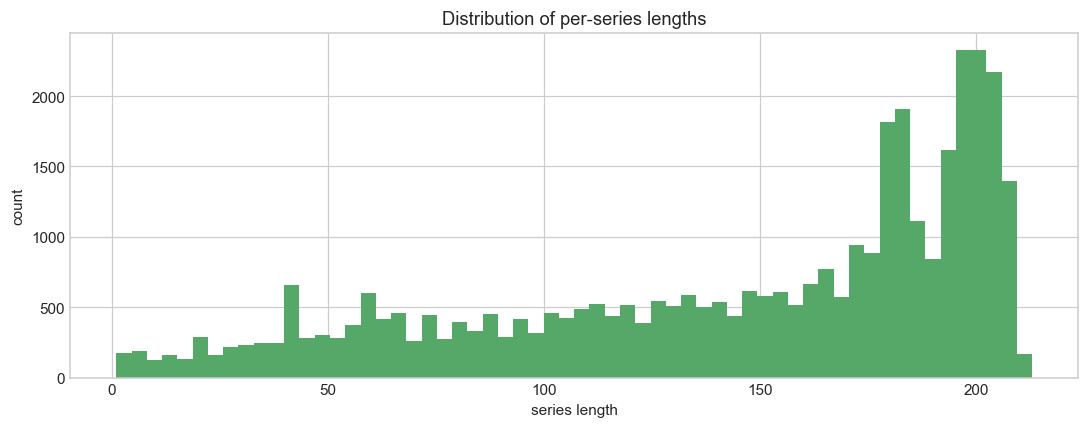

In [65]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(series_stats['length'], bins=60, color='#55A868')
ax.set_title('Distribution of per-series lengths')
ax.set_xlabel('series length')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

**Reading.** The panel has ~37K series but only a small fraction (~5%) cleanly crosses the validation cutoff. For the stationarity tests below, we restrict to **eligible series** (length ≥ 120 AND crosses cutoff) so every series has enough history and both a train and a validation portion.

## 7. Feature audit

The 86 `feature_*` columns are anonymized. We can't interpret them by name, but we can audit them statistically: missingness, variability, and correlation with the target.

In [66]:
sample = train[feature_cols + ['y_target']].sample(200_000, random_state=SEED)
corr_with_y = sample[feature_cols].corrwith(sample['y_target']).sort_values(key=abs, ascending=False)

print('Top 10 features by |correlation with target|:')
corr_with_y.head(10)

Top 10 features by |correlation with target|:


feature_bz    0.075793
feature_cd    0.073019
feature_af   -0.069717
feature_u    -0.065966
feature_s    -0.053064
feature_bo   -0.052483
feature_bm   -0.049170
feature_t    -0.037162
feature_am   -0.030793
feature_o    -0.028241
dtype: float64

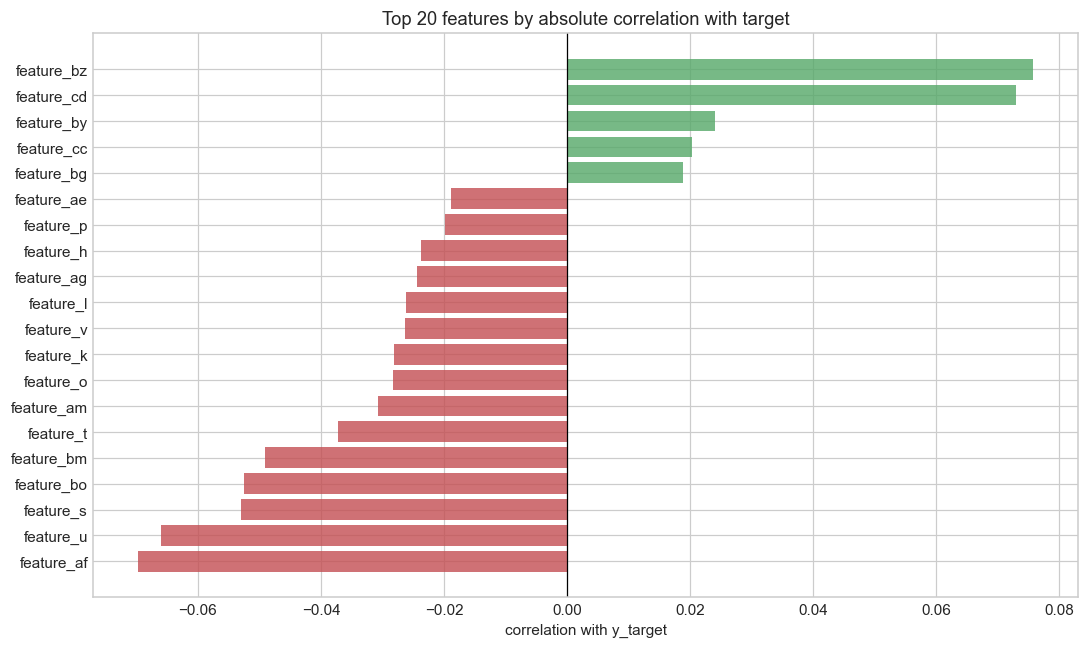

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))
top = corr_with_y.head(20).sort_values()
colors = ['#55A868' if v > 0 else '#C44E52' for v in top.values]
ax.barh(range(len(top)), top.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('correlation with y_target')
ax.set_title('Top 20 features by absolute correlation with target')
plt.tight_layout()
plt.show()

**Reading.** The single largest |correlation| is under 0.10. No feature alone predicts the target. That doesn't mean features are useless — gradient-boosted trees and neural nets combine weak signals effectively — but it does mean **no linear model on raw features** will work well.

## 8. Representative series

Instead of looking at arbitrary series, we pick four with clear reasons: longest history, highest total weight, most volatile, and most stable. This gives us a rounded picture of the panel rather than a cherry-picked one.

In [68]:
eligible = series_stats[(series_stats['crosses_cutoff']) & (series_stats['length'] >= 120)].copy()
eligible['target_std'] = eligible['target_std'].fillna(0.0)
stable_pool = eligible[eligible['target_std'] > 0]

chosen = pd.concat([
    eligible.nlargest(1, 'length').assign(reason='longest history'),
    eligible.nlargest(1, 'total_weight').assign(reason='highest total weight'),
    eligible.nlargest(1, 'target_std').assign(reason='most volatile'),
    stable_pool.nsmallest(1, 'target_std').assign(reason='most stable'),
], ignore_index=True).drop_duplicates(subset=series_keys)

chosen[[*series_keys, 'reason', 'length', 'total_weight', 'target_std']]

,code,sub_code,sub_category,horizon,reason,length,total_weight,target_std
0,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,longest history,212,9.060035e+02,2.641558
1,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,highest total weight,156,4.349747e+10,0.000394
2,W4S29LF4,KL66VIS3,PHHHVYZI,25,most volatile,162,4.562944e-01,296.760011
3,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,most stable,170,3.869062e+10,0.000139


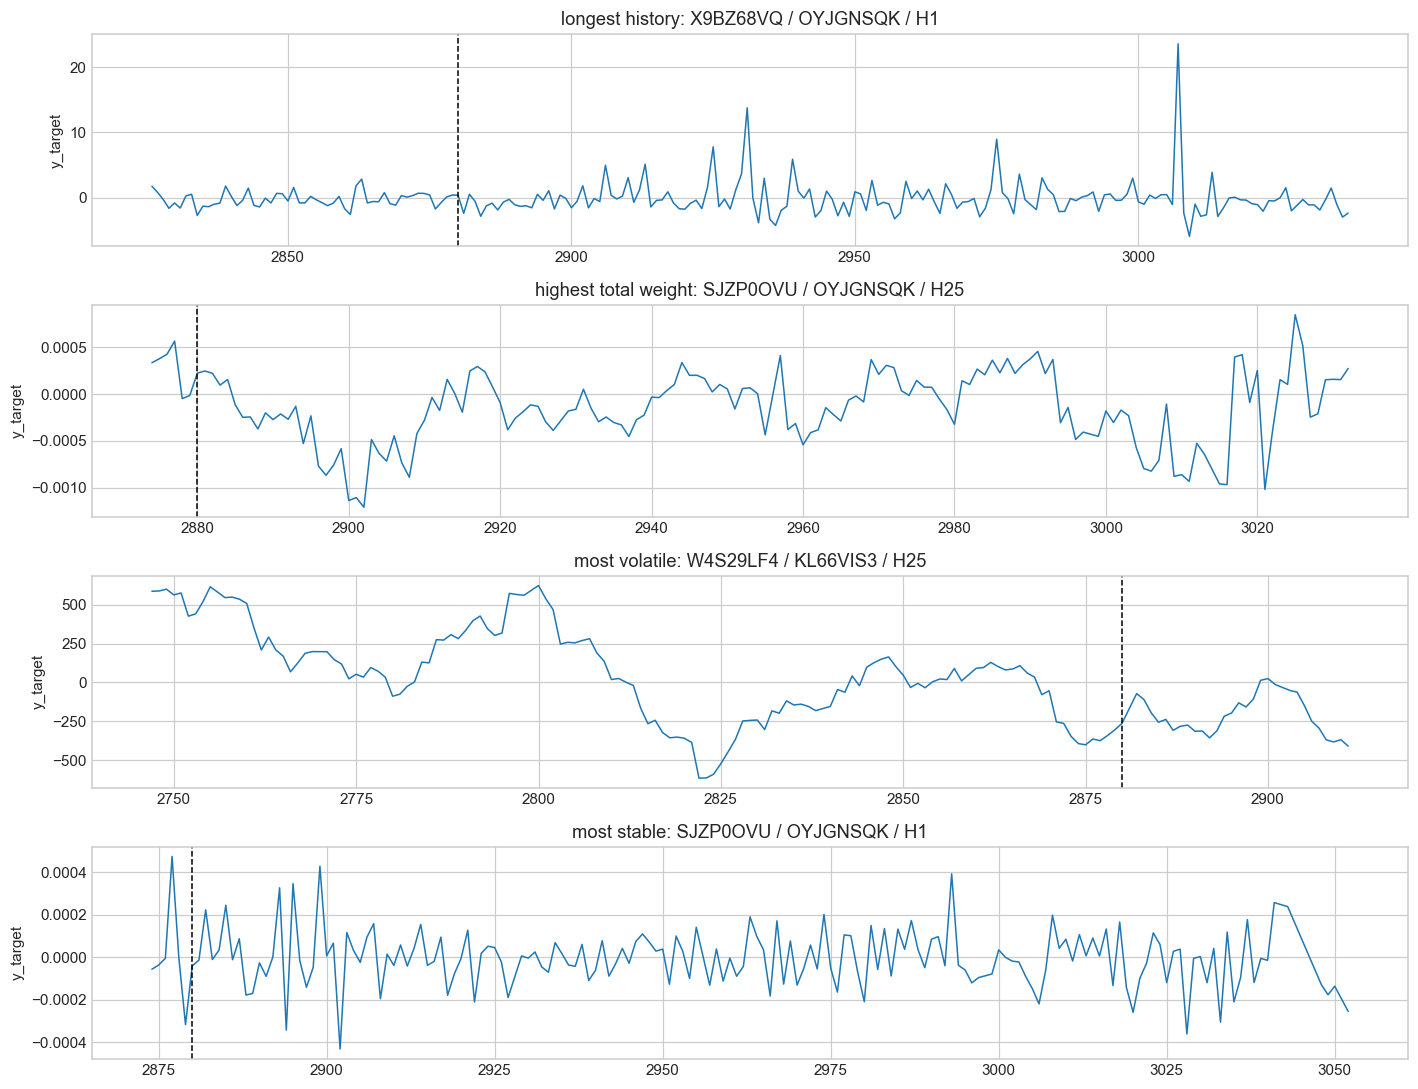

In [69]:
def get_series(row):
    mask = (
        (train['code'] == row['code'])
        & (train['sub_code'] == row['sub_code'])
        & (train['sub_category'] == row['sub_category'])
        & (train['horizon'] == row['horizon'])
    )
    return train.loc[mask, ['ts_index', 'y_target']].sort_values('ts_index').reset_index(drop=True)

fig, axes = plt.subplots(len(chosen), 1, figsize=(13, 10), sharex=False)
for ax, (_, row) in zip(axes, chosen.iterrows()):
    s = get_series(row)
    ax.plot(s['ts_index'], s['y_target'], linewidth=1)
    ax.axvline(VAL_CUTOFF, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{row['reason']}: {row['code']} / {row['sub_code']} / H{row['horizon']}")
    ax.set_ylabel('y_target')
plt.tight_layout()
plt.show()

**Reading.** The four panels look very different from each other — which is itself the key lesson. A "one-size-fits-all" model is unlikely to work; we need a **global model with panel identifiers** so it can behave differently for different series.

## 9. Stationarity — ADF test

A series is **stationary** when its mean, variance, and autocorrelation structure don't change over time. Classical forecasting models like ARIMA assume stationarity (after differencing). Before we train them, we need to check.

**Reminder on what a "series" is in this panel.** A series is uniquely identified by the combination `(code, sub_code, sub_category, horizon)` — four keys, not one. We run one ADF test per series, and store all four keys on the result row so we can break down stationarity by any of them afterwards.

The **Augmented Dickey-Fuller (ADF)** test has:
- **H0:** the series has a unit root (is non-stationary).
- **H1:** the series is stationary.

So if the **p-value < 0.05**, we reject H0 and conclude the series is **stationary**.

We run ADF on a sample of eligible series (length ≥ 120 AND crosses VAL_CUTOFF) and report the panel-level fraction that are stationary.

In [70]:
sample_ids = eligible.sample(n=min(200, len(eligible)), random_state=SEED).reset_index(drop=True)
print(f'Sampling {len(sample_ids)} eligible series for stationarity testing')

def safe_adf(series):
    """Run ADF and return (stat, pvalue) or (nan, nan) on failure."""
    y = pd.Series(series).dropna().values
    if len(y) < 20 or np.std(y) == 0:
        return np.nan, np.nan
    try:
        stat, pvalue, *_ = adfuller(y, autolag='AIC')
        return stat, pvalue
    except Exception:
        return np.nan, np.nan

# A series is uniquely defined by (code, sub_code, sub_category, horizon).
# We store all four keys on each ADF row so every result points back to its series.
adf_rows = []
for _, row in sample_ids.iterrows():
    s = get_series(row)
    stat, pv = safe_adf(s['y_target'])
    adf_rows.append({
        'code': row['code'],
        'sub_code': row['sub_code'],
        'sub_category': row['sub_category'],
        'horizon': row['horizon'],
        'length': row['length'],
        'adf_stat': stat,
        'adf_p': pv,
    })
adf_df = pd.DataFrame(adf_rows)
adf_df['stationary_5pct'] = adf_df['adf_p'] < 0.05

print('ADF summary:')
print(f'  successful tests: {adf_df["adf_p"].notna().sum()} / {len(adf_df)}')
print(f'  stationary at 5%: {adf_df["stationary_5pct"].sum()} '
      f'({adf_df["stationary_5pct"].mean():.1%})')
adf_df.head()

Sampling 200 eligible series for stationarity testing
ADF summary:
  successful tests: 200 / 200
  stationary at 5%: 138 (69.0%)


,code,sub_code,sub_category,horizon,length,adf_stat,adf_p,stationary_5pct
0,VFWIFJPS,OYJGNSQK,PHHHVYZI,25,156,-2.466184,0.123920,False
1,MLAAMU3K,KL66VIS3,DPPUO5X2,25,182,-2.594808,0.094075,False
2,SJZP0OVU,OYJGNSQK,V8BKY1IV,10,162,-5.225014,0.000008,True
3,84J8BJFZ,KL66VIS3,PHHHVYZI,3,204,-3.204251,0.019740,True
4,84J8BJFZ,6CVIDNCZ,PHHHVYZI,3,204,-3.644879,0.004959,True


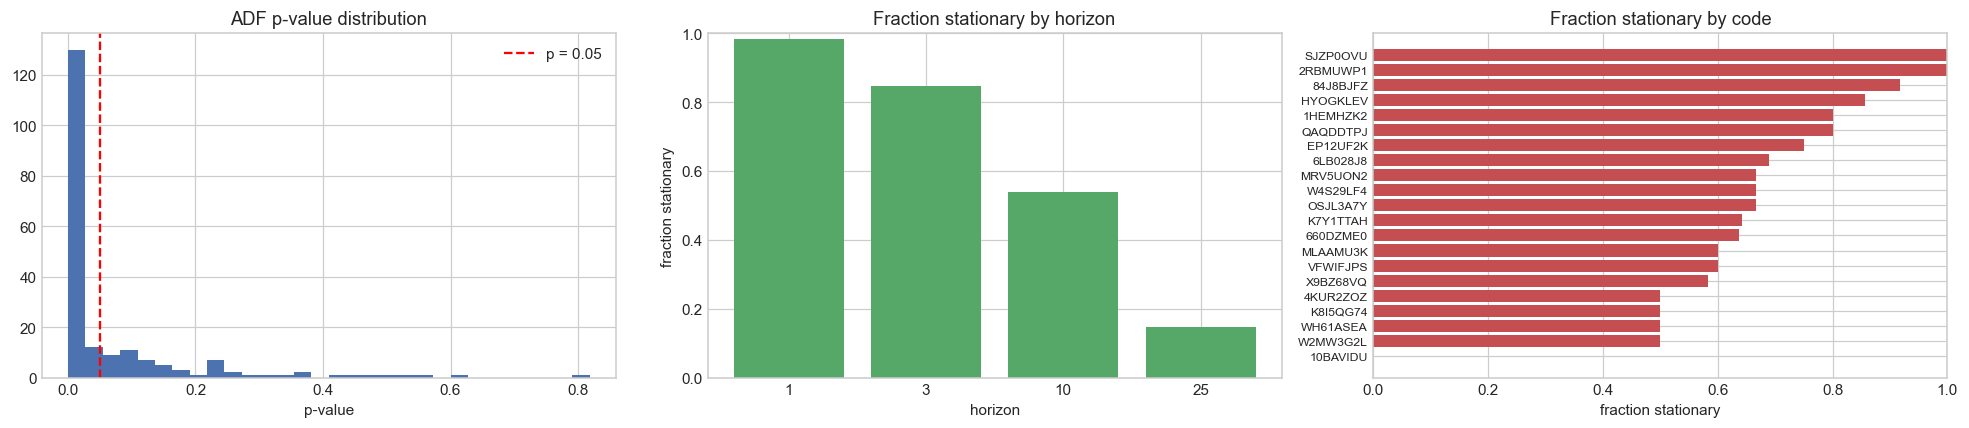

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (1) p-value distribution
axes[0].hist(adf_df['adf_p'].dropna(), bins=30, color='#4C72B0')
axes[0].axvline(0.05, color='red', linestyle='--', label='p = 0.05')
axes[0].set_title('ADF p-value distribution')
axes[0].set_xlabel('p-value')
axes[0].legend()

# (2) breakdown by horizon (4 bars)
by_horizon = adf_df.groupby('horizon')['stationary_5pct'].mean()
axes[1].bar(by_horizon.index.astype(str), by_horizon.values, color='#55A868')
axes[1].set_title('Fraction stationary by horizon')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('fraction stationary')
axes[1].set_ylim(0, 1)

# (3) breakdown by code (up to 23 bars) — code is the primary series identifier
by_code = adf_df.groupby('code')['stationary_5pct'].mean().sort_values()
axes[2].barh(range(len(by_code)), by_code.values, color='#C44E52')
axes[2].set_yticks(range(len(by_code)))
axes[2].set_yticklabels(by_code.index, fontsize=8)
axes[2].set_title('Fraction stationary by code')
axes[2].set_xlabel('fraction stationary')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.show()

**Reading.** Three views of the same test:

1. **p-value histogram** — a pile to the left of the red line means most series reject H0 → stationary. A pile to the right means most are non-stationary and we probably need differencing (see §11).
2. **By horizon** — are the 4 horizons behaving differently? If so, per-horizon model defaults may help.
3. **By code** — code is the primary series identifier. If some codes are almost entirely stationary and others aren't, the modeling strategy could split on code (or at least let a global model learn code-specific behavior).

## 10. Stationarity — KPSS test (ADF complement)

ADF and KPSS have **opposite null hypotheses**, which is why people usually run both:
- **ADF:** H0 = has unit root (non-stationary).
- **KPSS:** H0 = is stationary.

The 2x2 table of outcomes is:

| ADF | KPSS | Conclusion |
| --- | --- | --- |
| reject H0 (p<0.05) | fail to reject (p≥0.05) | **Stationary** |
| fail to reject | reject | **Unit root** (needs differencing) |
| reject | reject | inconclusive, may be trend-stationary |
| fail to reject | fail to reject | inconclusive, low power (short series) |

In [72]:
def safe_kpss(series):
    y = pd.Series(series).dropna().values
    if len(y) < 20 or np.std(y) == 0:
        return np.nan
    try:
        stat, pvalue, *_ = kpss(y, regression='c', nlags='auto')
        return pvalue
    except Exception:
        return np.nan

kpss_pvals = []
for _, row in sample_ids.iterrows():
    s = get_series(row)
    kpss_pvals.append(safe_kpss(s['y_target']))
adf_df['kpss_p'] = kpss_pvals
adf_df['kpss_stationary_5pct'] = adf_df['kpss_p'] >= 0.05  # KPSS: stationary if FAIL to reject

both = adf_df.dropna(subset=['adf_p', 'kpss_p']).copy()
both['verdict'] = np.where(both['stationary_5pct'] & both['kpss_stationary_5pct'], 'stationary',
                  np.where(~both['stationary_5pct'] & ~both['kpss_stationary_5pct'], 'unit root',
                           'inconclusive'))
print('Joint ADF + KPSS verdict:')
print(both['verdict'].value_counts(normalize=True).round(3))

Joint ADF + KPSS verdict:
verdict
stationary      0.640
inconclusive    0.255
unit root       0.105
Name: proportion, dtype: float64


**Reading.** The joint verdict is the honest answer. If "stationary" dominates, ARIMA `d=0` or simple baselines are fine. If "unit root" dominates, we need differencing. A large "inconclusive" share is itself useful information — it means the series are short or noisy enough that statistical tests don't give a clean signal, and we should lean on robust global models rather than per-series ARIMA.

## 11. Differencing analysis

If raw series aren't stationary, a common fix is to take first differences: `diff_y[t] = y[t] - y[t-1]`. We re-run ADF on the differenced series to see whether this fixes it.

In [73]:
diff_rows = []
for _, row in sample_ids.iterrows():
    s = get_series(row)
    y_diff = s['y_target'].diff().dropna()
    stat, pv = safe_adf(y_diff)
    diff_rows.append(pv)
adf_df['adf_p_diff'] = diff_rows
adf_df['stationary_after_diff'] = adf_df['adf_p_diff'] < 0.05

print(f"Stationary in LEVELS (d=0): {adf_df['stationary_5pct'].mean():.1%}")
print(f"Stationary after DIFFERENCING (d=1): {adf_df['stationary_after_diff'].mean():.1%}")

Stationary in LEVELS (d=0): 69.0%
Stationary after DIFFERENCING (d=1): 100.0%


**Reading.** If the d=1 fraction is noticeably higher than d=0, differencing helps and ARIMA should default to `d=1`. If both are already high, the panel is stationary in levels and `d=0` is enough. This is exactly the number we need when we set ARIMA defaults in the classical-models notebook.

## 12. Rolling mean / variance (visual stationarity)

Statistical tests can disagree on short or noisy series. A rolling plot is the simplest *visual* way to confirm. If the rolling mean and rolling std are roughly flat lines, the series looks stationary to the eye.

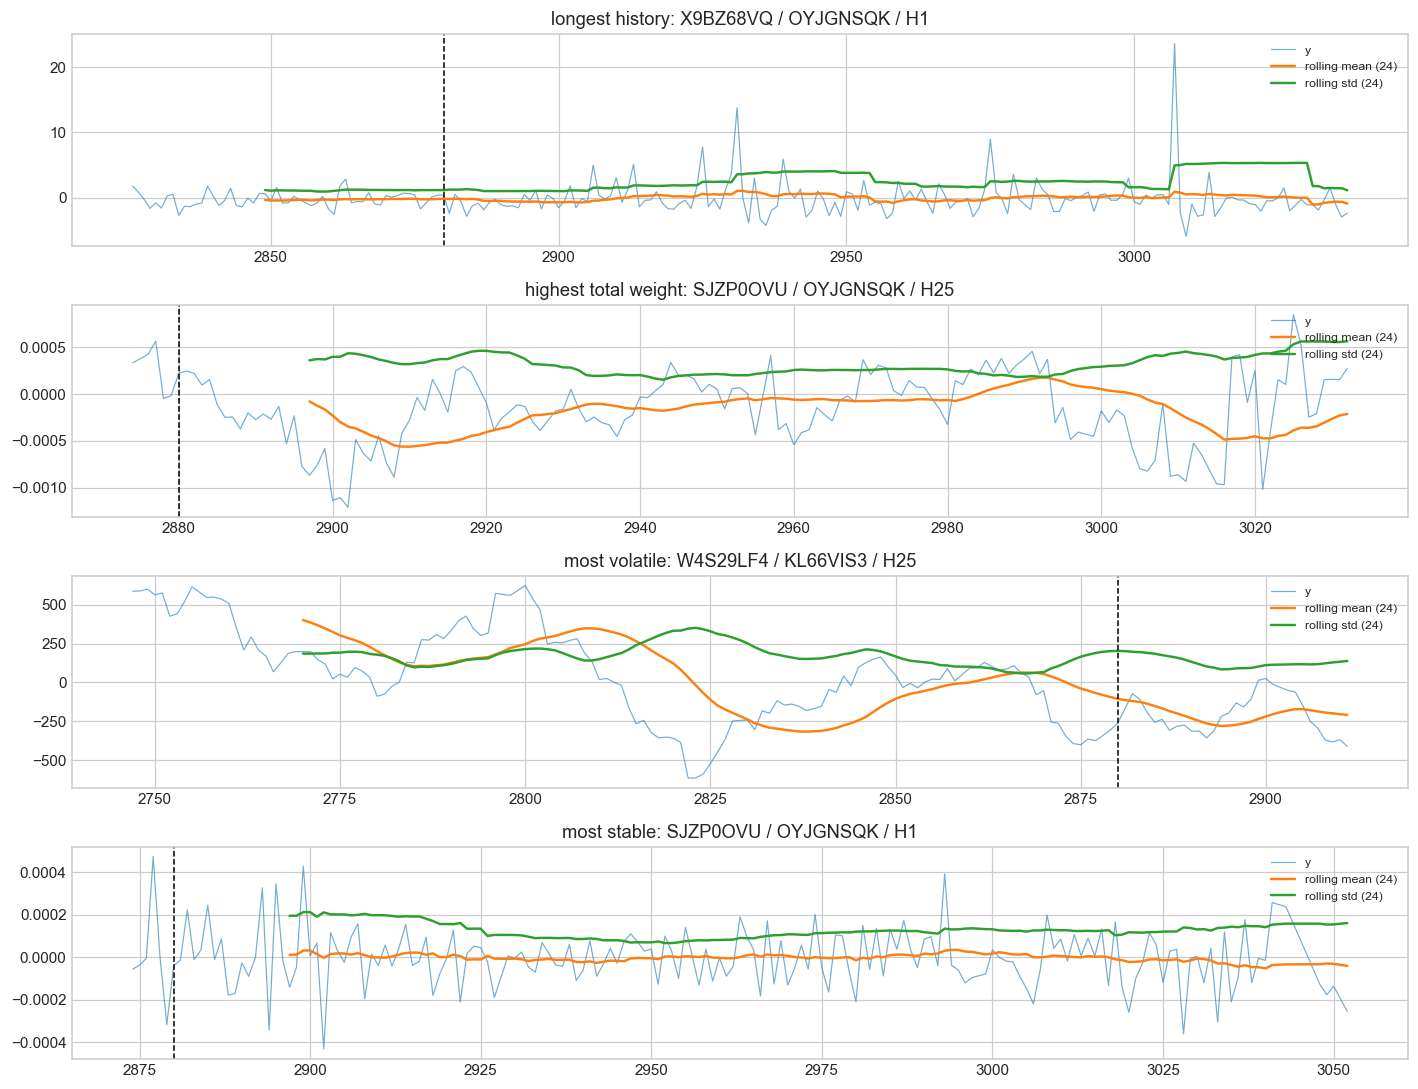

In [74]:
window = 24
fig, axes = plt.subplots(len(chosen), 1, figsize=(13, 10), sharex=False)
for ax, (_, row) in zip(axes, chosen.iterrows()):
    s = get_series(row)
    y = s['y_target']
    ax.plot(s['ts_index'], y, linewidth=0.8, alpha=0.6, label='y')
    ax.plot(s['ts_index'], y.rolling(window).mean(), linewidth=1.6, label=f'rolling mean ({window})')
    ax.plot(s['ts_index'], y.rolling(window).std(), linewidth=1.6, label=f'rolling std ({window})')
    ax.axvline(VAL_CUTOFF, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{row['reason']}: {row['code']} / {row['sub_code']} / H{row['horizon']}")
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**Reading.** A flat rolling mean suggests constant-mean behavior. A flat rolling std suggests constant variance (homoskedasticity). Slopes or bulges in either curve are evidence against stationarity — and in this panel, the most-volatile series will almost certainly show a non-flat rolling std.

### 12b. Same plot, but on the first-differenced series

§11 told us that after differencing, essentially all series pass ADF. That is a *statistical* claim. To confirm it *visually* — which is what this section is for — we repeat the rolling mean / std plots on `y.diff()` instead of `y`. If differencing really fixes non-stationarity, both curves should flatten out.

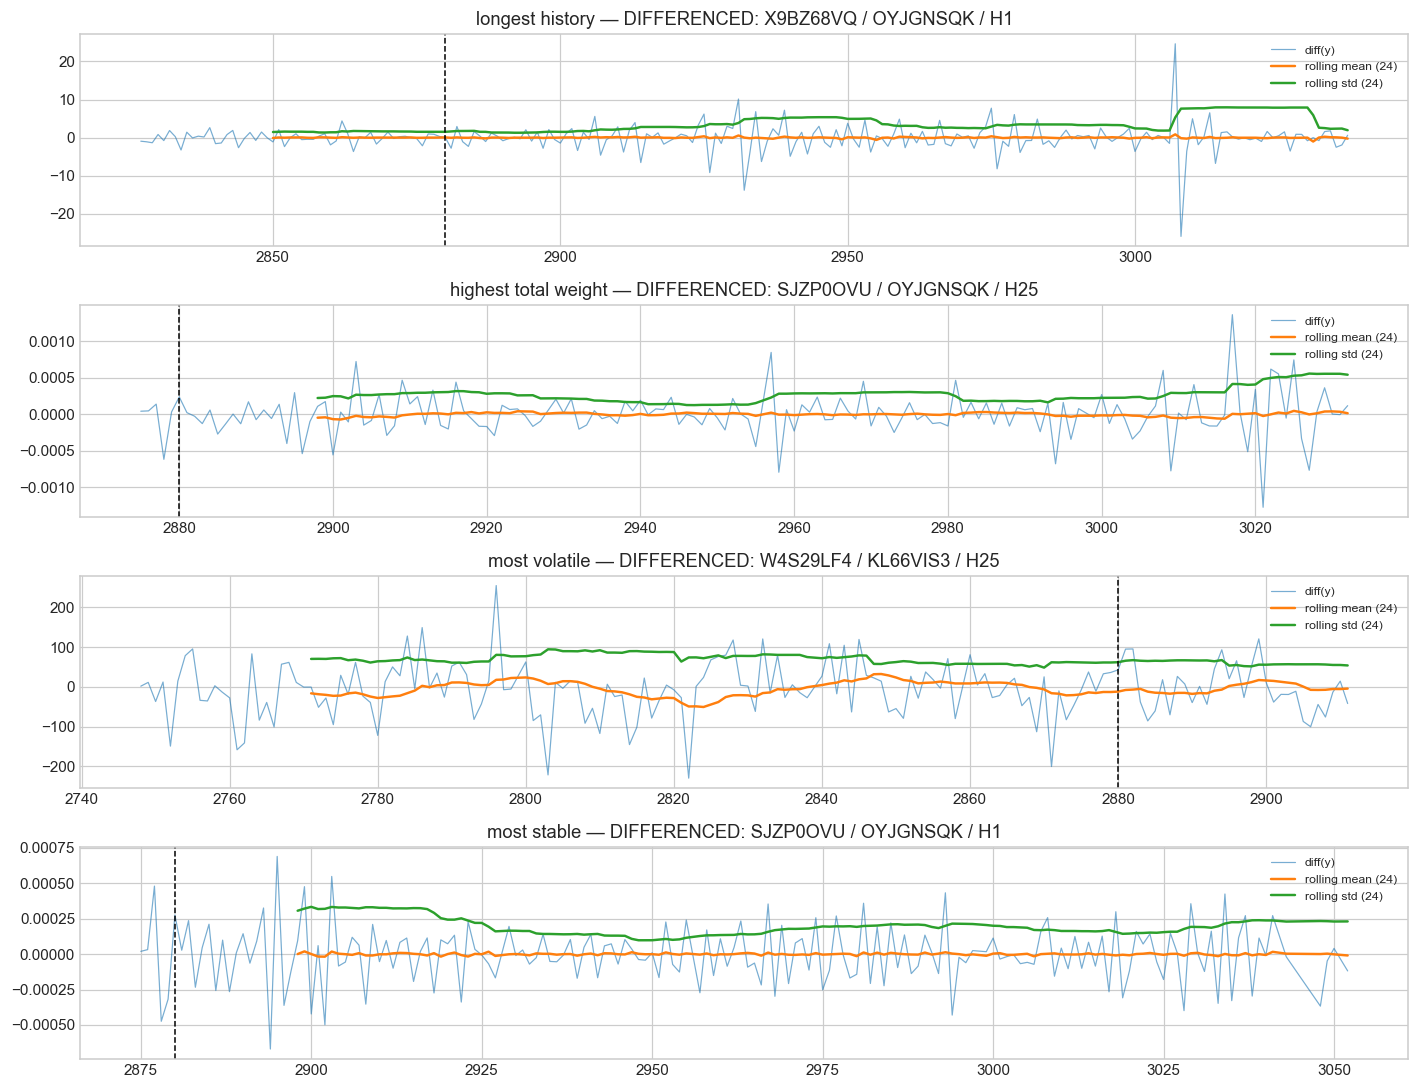

In [75]:
window = 24
fig, axes = plt.subplots(len(chosen), 1, figsize=(13, 10), sharex=False)
for ax, (_, row) in zip(axes, chosen.iterrows()):
    s = get_series(row)
    y_diff = s['y_target'].diff()
    ax.plot(s['ts_index'], y_diff, linewidth=0.8, alpha=0.6, label='diff(y)')
    ax.plot(s['ts_index'], y_diff.rolling(window).mean(), linewidth=1.6, label=f'rolling mean ({window})')
    ax.plot(s['ts_index'], y_diff.rolling(window).std(), linewidth=1.6, label=f'rolling std ({window})')
    ax.axvline(VAL_CUTOFF, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{row['reason']} — DIFFERENCED: {row['code']} / {row['sub_code']} / H{row['horizon']}")
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**Reading.** Compare these panels with the raw versions just above. Expected pattern after differencing:

- **Rolling mean** hugs zero throughout — differencing removes slow-moving trend, so the mean drifts disappear.
- **Rolling std** is flatter than in levels — not perfectly flat for heavy-tailed series, but with no systematic ramp.
- The differenced *y* itself looks noisier and more zero-centered than the raw *y*.

This is exactly the visual signature of stationarity, and it matches the 100% figure from §11. Together, §11 (statistical: ADF p < 0.05 on the differences) and §12b (visual: flat rolling moments) make the case that **d = 1 is the right default** for any ARIMA model we fit downstream.

## 13. ACF and PACF — anchor series

**ACF (autocorrelation function)** shows how correlated the series is with its past values at each lag. Persistent bars far from zero mean "yesterday predicts today".

**PACF (partial autocorrelation function)** strips out the indirect effects via shorter lags — the PACF at lag k tells you the *direct* contribution of lag k once lags 1..k-1 are accounted for.

As a rule of thumb:
- PACF cutoff at lag p, ACF decaying → suggests **AR(p)**.
- ACF cutoff at lag q, PACF decaying → suggests **MA(q)**.
- Both decaying → ARMA.

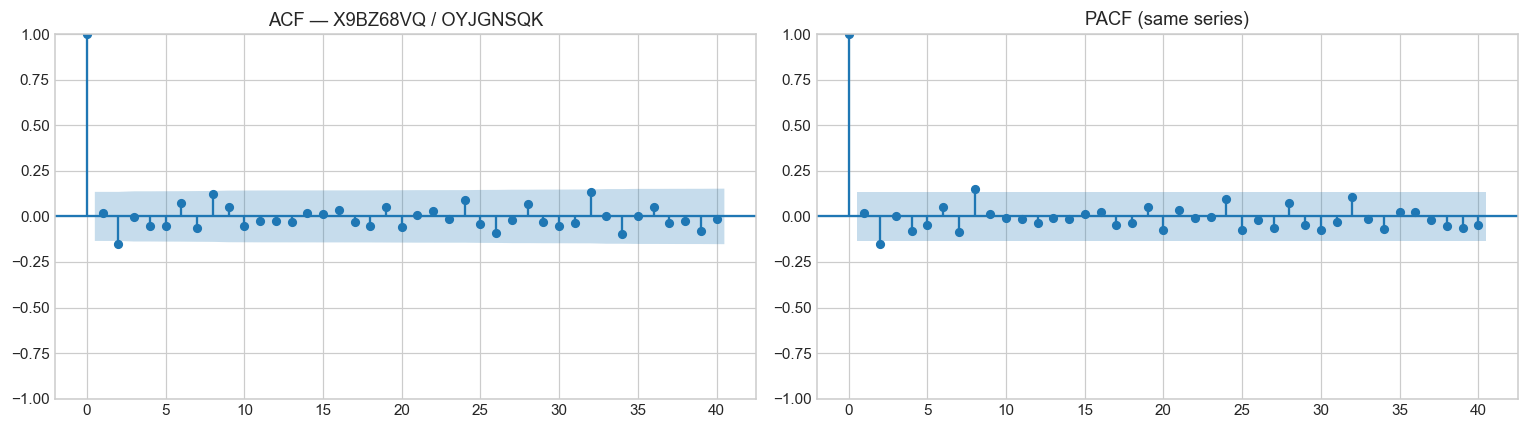

In [76]:
# pick the longest-history series as the anchor
anchor_row = chosen[chosen['reason'] == 'longest history'].iloc[0]
anchor = get_series(anchor_row)['y_target'].reset_index(drop=True)
max_lag = min(40, len(anchor) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(anchor, lags=max_lag, ax=axes[0])
axes[0].set_title(f"ACF — {anchor_row['code']} / {anchor_row['sub_code']}")
plot_pacf(anchor, lags=max_lag, ax=axes[1], method='ywm')
axes[1].set_title('PACF (same series)')
plt.tight_layout()
plt.show()

**Reading.** Look at which lags are outside the blue confidence band. Those are the lags that carry real signal. If the PACF dies after lag 1–2 while the ACF decays slowly, an **AR(1) or AR(2)** baseline is reasonable. If both die quickly, low-order lag features are enough and complex AR(p) is overkill.

## 14. ACF and PACF — panel-level

A single series can mislead. We compute ACF/PACF on every sampled eligible series, then aggregate. The result is a *panel-typical* autocorrelation profile.

Aggregated over 200 series


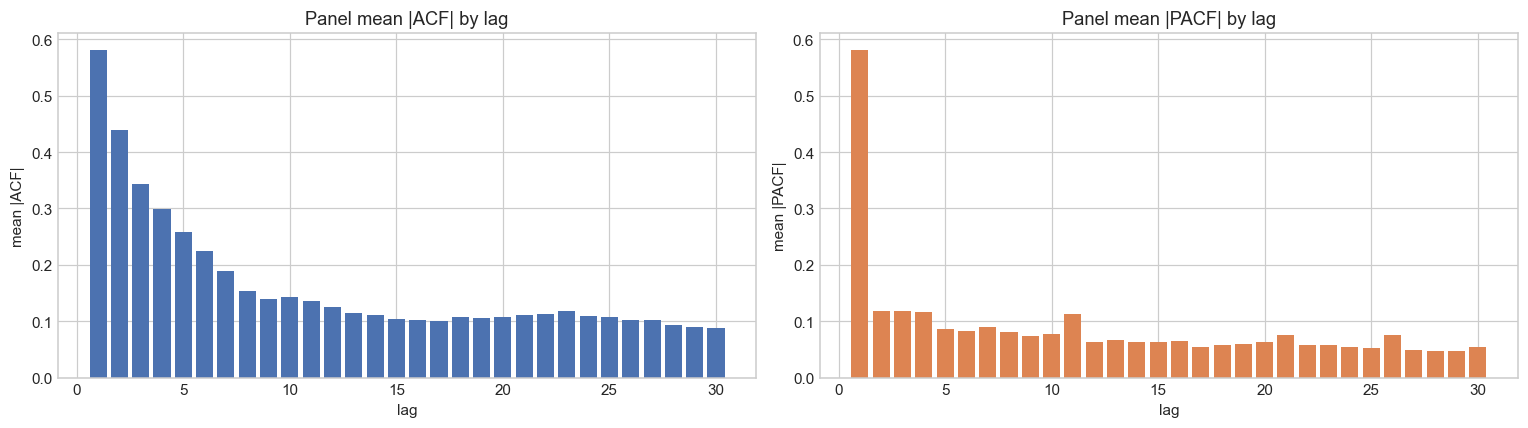

Top 5 lags by mean |ACF|: [1, 2, 3, 4, 5]


In [77]:
K = 30  # max lag
acf_mat, pacf_mat = [], []
for _, row in sample_ids.iterrows():
    y = get_series(row)['y_target'].dropna().values
    if len(y) < 2 * K + 5 or np.std(y) == 0:
        continue
    try:
        acf_mat.append(acf(y, nlags=K, fft=True))
        pacf_mat.append(pacf(y, nlags=K, method='ywm'))
    except Exception:
        continue

acf_mat = np.array(acf_mat)
pacf_mat = np.array(pacf_mat)
print(f'Aggregated over {len(acf_mat)} series')

mean_abs_acf = np.nanmean(np.abs(acf_mat), axis=0)
mean_abs_pacf = np.nanmean(np.abs(pacf_mat), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1, K + 1), mean_abs_acf[1:], color='#4C72B0')
axes[0].set_title('Panel mean |ACF| by lag')
axes[0].set_xlabel('lag'); axes[0].set_ylabel('mean |ACF|')

axes[1].bar(range(1, K + 1), mean_abs_pacf[1:], color='#DD8452')
axes[1].set_title('Panel mean |PACF| by lag')
axes[1].set_xlabel('lag'); axes[1].set_ylabel('mean |PACF|')
plt.tight_layout()
plt.show()

top_lags = np.argsort(mean_abs_acf[1:])[::-1][:5] + 1
print(f'Top 5 lags by mean |ACF|: {top_lags.tolist()}')

**Reading.** These bars tell us which lags the **lag-feature set for the ML models should prioritize**. If lags 1, 2, 3 dominate, simple short-term lags are enough. If we see bumps at lag 24 or 25, there may be weekly/monthly seasonality. The PACF plot narrows this down to *direct* dependence and is the better guide for AR order.

## 15. Seasonality strength scan

For each candidate period `p`, we fit STL and compute a *seasonality strength* in [0, 1]:

`F_s = max(0, 1 - var(residual) / var(residual + seasonal))`

Closer to 1 → strong seasonality at that period. Closer to 0 → negligible seasonality.

In [78]:
candidate_periods = [3, 5, 7, 10, 20, 25, 50]

def seasonality_strength(y, period):
    if len(y) < 2 * period + 1 or np.std(y) == 0:
        return np.nan
    try:
        res = STL(pd.Series(y), period=period, robust=True).fit()
        denom = np.nanvar(res.resid + res.seasonal)
        return max(0.0, 1 - np.nanvar(res.resid) / (denom + 1e-12))
    except Exception:
        return np.nan

rows = []
for _, row in chosen.iterrows():
    y = get_series(row)['y_target'].values
    for p in candidate_periods:
        rows.append({'reason': row['reason'], 'period': p,
                     'F_seasonal': seasonality_strength(y, p)})
season_df = pd.DataFrame(rows).pivot(index='reason', columns='period', values='F_seasonal')
season_df.round(3)

period,3,5,7,10,20,25,50
reason,,,,,,,
highest total weight,0.000,0.174,0.193,0.000,0.133,0.157,0.553
longest history,0.098,0.061,0.027,0.031,0.069,0.017,0.231
most stable,0.038,0.206,0.163,0.123,0.045,0.048,0.433
most volatile,0.000,0.100,0.118,0.004,0.111,0.000,0.594


**Reading.** If any column (period) is consistently high across rows (series), that period is a panel-level seasonal candidate. If every cell is low (say < 0.2), this is a non-seasonal panel and classical seasonal ARIMA (SARIMA) is not worth pursuing.

## 17. Cross-series relationships

Within the same `code` bucket, different sub-codes might share information. If so, **global models** that pool across sub-codes will outperform per-series ARIMA.

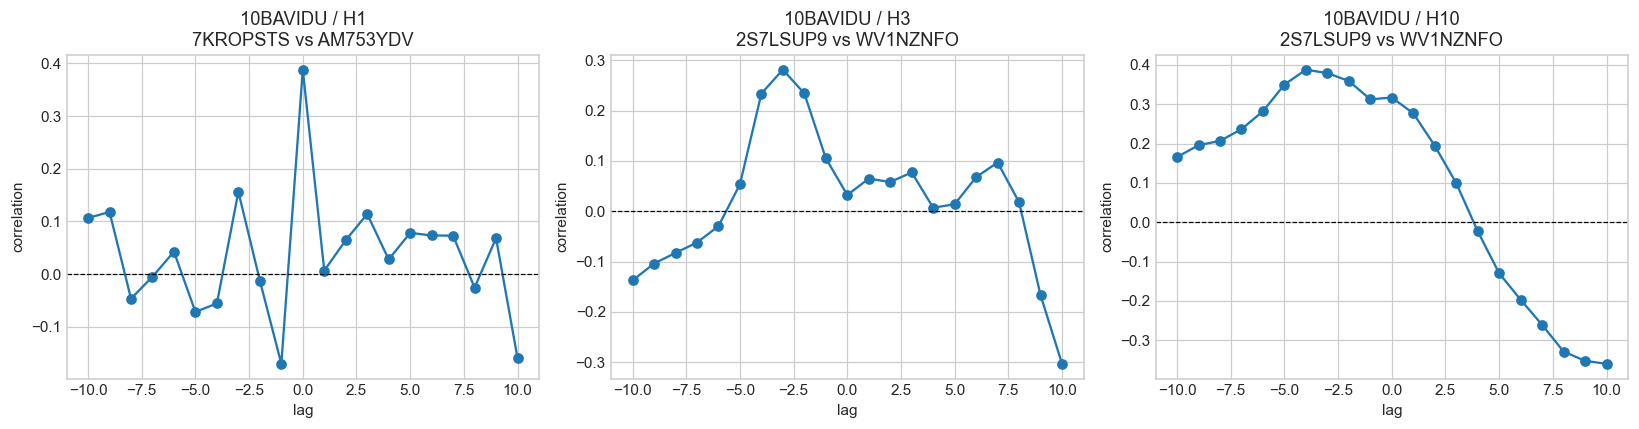

In [80]:
pair_candidates = []
for (code_value, horizon_value), grp in train.groupby(['code', 'horizon']):
    if grp['sub_code'].nunique() < 2:
        continue
    pivot = grp.pivot_table(index='ts_index', columns='sub_code', values='y_target', aggfunc='mean')
    cols = list(pivot.columns)
    best = (0, None, None)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            overlap = pivot[[cols[i], cols[j]]].dropna().shape[0]
            if overlap > best[0]:
                best = (overlap, cols[i], cols[j])
    if best[0] > 50:
        pair_candidates.append((code_value, horizon_value, pivot, best[1], best[2], best[0]))
    if len(pair_candidates) == 3:
        break

fig, axes = plt.subplots(1, len(pair_candidates), figsize=(5 * len(pair_candidates), 4))
axes = np.atleast_1d(axes)
for ax, (code_v, h_v, pivot, c1, c2, overlap) in zip(axes, pair_candidates):
    corrs = []
    for lag in range(-10, 11):
        aligned = pd.concat([pivot[c1], pivot[c2].shift(lag)], axis=1).dropna()
        if len(aligned) > 3 and aligned.iloc[:, 0].nunique() > 1 and aligned.iloc[:, 1].nunique() > 1:
            corrs.append(aligned.corr().iloc[0, 1])
        else:
            corrs.append(np.nan)
    ax.plot(range(-10, 11), corrs, marker='o')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{code_v} / H{h_v}\n{c1} vs {c2}')
    ax.set_xlabel('lag')
    ax.set_ylabel('correlation')
plt.tight_layout()
plt.show()

**Reading.** A clear peak away from zero lag means one series *leads* or *lags* the other. That kind of cross-series structure is exactly what global models (LightGBM / XGBoost with series identifiers) can exploit but per-series ARIMA cannot.

## 18. Leakage and split sanity

Before we conclude, a quick safety check: is there anything in the raw schema that would leak future information into training?

In [81]:
split_check = pd.DataFrame({
    'partition': ['train_pre_cutoff', 'train_post_cutoff', 'test'],
    'rows': [
        int((train['ts_index'] <= VAL_CUTOFF).sum()),
        int((train['ts_index'] > VAL_CUTOFF).sum()),
        int(len(test)),
    ],
})
print('train-only columns:', sorted(set(train.columns) - set(test.columns)))
print('test-only columns:', sorted(set(test.columns) - set(train.columns)))
split_check

train-only columns: ['weight', 'y_target']
test-only columns: []


,partition,rows
0,train_pre_cutoff,4121749
1,train_post_cutoff,1215665
2,test,1447107


**Reading.** The only train-only columns are `y_target` and `weight`, which is correct — the labels and metric weights are only on the train side. No obvious schema-level leakage.

## 19. Conclusions for modeling

Bringing it all together:

**Panel structure**
- Large panel, 23 codes × 180 sub-codes × 5 sub-categories × 4 horizons.
- Test is a strict temporal suffix (ts_index 3602–4376) with a narrower sub-code universe. Use **time-based validation**, never random CV.

**Target and weight**
- Target has heavy tails; a few rows carry a disproportionate share of the metric (**~65% of weight in the top 1% of rows**).
- Evaluation **must** use the weighted skill score. Unweighted RMSE will mislead.

**Stationarity (§9–§12)**
- The ADF / KPSS results tell us whether ARIMA should default to `d=0` or `d=1`.
- The differencing re-test (§11) gives the direct answer — look at the two percentages printed there.
- The rolling-mean/variance plots (§12) confirm the statistical answer visually.

**Autocorrelation (§13–§14)**
- The top lags from the panel mean |ACF| plot are the lags the ML models' **lag-feature set** should include.
- The PACF plot guides AR order if we fit ARIMA.

**Seasonality (§15)**
- Only go for SARIMA / seasonal features if the F_seasonal table has a column that is consistently strong (say > 0.3) across representative series. Otherwise treat this as a non-seasonal panel.

**Exploitable signal (§16)**
- The Ljung-Box fraction tells us how much room there is above a naive / drift baseline. If it is low, calibrate expectations accordingly.

**Modeling path**
- Classical models (ETS, ARIMA): fine as baselines with the `d` we determined.
- ML global models (LightGBM, XGBoost): best fit for this panel given weak individual feature correlations (§7) and cross-series structure (§17).
- Deep learning: plausible but only compare fairly against ML models that use the same feature scope.